# QAD recovery curves (vLLM evals)

Parses `qad/eval_results_vllm/` and plots benchmark accuracy vs QAD training step
for each quantization method, with the full-precision BF16 baseline as a horizontal line.

In [5]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt

VLLM_DIR = Path("../qad/eval_results_vllm")
MODEL = "Qwen-Qwen3-4B"

# task -> (display title, preferred metric key). Metric keys vary by task filter:
#   - math500          : symbolic math_verify,none
#   - mmlu_flan_cot_*   : CoT generative MMLU; a GROUP whose top-level row is empty —
#                         the metric lives on 57 subject leaves (exact_match,flexible-extract),
#                         so get_metric() sample-weight-aggregates the leaves.
#   - mmlu_pro         : CoT; aggregates at the group level as exact_match,custom-extract.
TASKS = {
    "gsm8k":                  ("GSM8K",      "exact_match,flexible-extract"),
    "minerva_math500":        ("MATH-500",   "math_verify,none"),
    # "aime25":                 ("AIME-2025",  "exact_match,none"),
    "mmlu_flan_cot_zeroshot": ("MMLU (CoT)", "exact_match,flexible-extract"),
    "mmlu_pro":               ("MMLU-Pro",   "exact_match,custom-extract"),
}


def _leaf_metric(m, key):
    if key in m:
        return m[key]
    for k, v in m.items():
        if k.startswith(("exact_match,", "math_verify,")) and not k.endswith("_stderr"):
            return v
    return None


def get_metric(doc, task, key):
    results = doc.get("results", {})
    r = results.get(task, {})
    # 1) direct metric on the task / group aggregate row
    v = _leaf_metric(r, key)
    if v is not None:
        return v
    # 2) group with an empty top-level row: sample-weighted mean over subject leaves
    #    (keys like "<task>_abstract_algebra"; excludes "<task>::category" mid-groups).
    num = den = 0.0
    for t, m in results.items():
        if t == task or not t.startswith(task + "_"):
            continue
        lv = _leaf_metric(m, key)
        if lv is None:
            continue
        w = m.get("sample_len") or 1
        num += lv * w
        den += w
    return num / den if den else None


def load_tag(tag_dir):
    """Return {task: {step: accuracy_pct}} for one checkpoint-tag directory."""
    out = {}
    for jf in sorted(tag_dir.glob("step_*.json")):
        m = re.search(r"step_(\d+)", jf.name)
        if not m:
            continue
        step = int(m.group(1))
        doc = json.loads(jf.read_text())
        for task, (_title, key) in TASKS.items():
            v = get_metric(doc, task, key)
            if v is not None:
                out.setdefault(task, {})[step] = float(v) * 100.0
    return out


baseline = {}   # task -> accuracy_pct  (BF16, unquantized)
methods = {}    # method_name -> {task: {step: accuracy_pct}}

for tag_dir in sorted(VLLM_DIR.glob("*")):
    if not tag_dir.is_dir():
        continue
    data = load_tag(tag_dir)
    if "unquantized" in tag_dir.name:
        for task, steps in data.items():
            if steps:
                baseline[task] = steps[min(steps)]  # single step-0 entry
    else:
        # tag: qad-Qwen-Qwen3-4B-<quantizer>-<8hexhash>  ->  method = <quantizer>
        mo = re.match(r".*-([A-Za-z0-9.]+)-[0-9a-f]{8}$", tag_dir.name)
        method = mo.group(1) if mo else tag_dir.name
        methods[method] = data

print("baseline:", {k: round(v, 1) for k, v in baseline.items()})
print("methods :", {m: {t: len(s) for t, s in d.items()} for m, d in methods.items()})

baseline: {'gsm8k': 89.2, 'minerva_math500': 82.4, 'mmlu_flan_cot_zeroshot': 74.9, 'mmlu_pro': 61.2}
methods : {'ste3bit': {'gsm8k': 9, 'minerva_math500': 9, 'mmlu_flan_cot_zeroshot': 9, 'mmlu_pro': 9}, 'ste4bit': {'gsm8k': 9, 'minerva_math500': 9}}


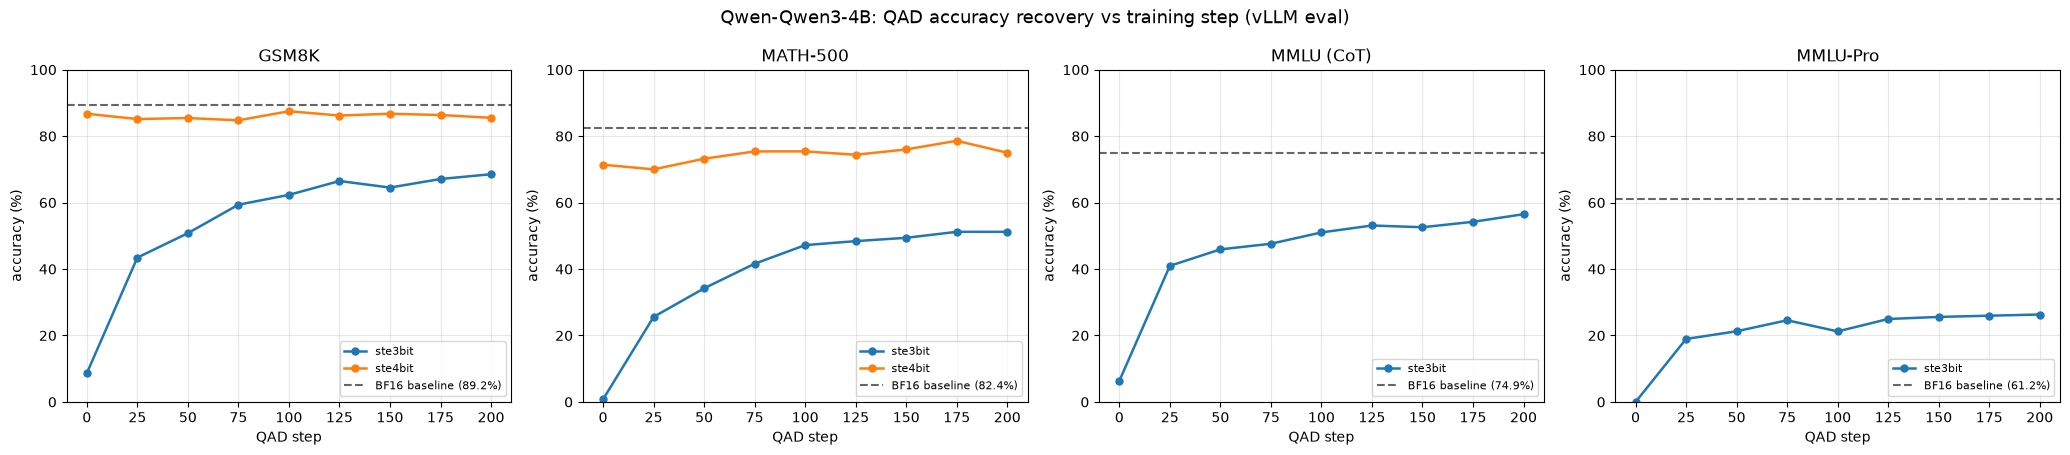

In [6]:
tasks = list(TASKS.keys())
fig, axes = plt.subplots(1, len(tasks), figsize=(5.2 * len(tasks), 4.6), squeeze=False)
axes = axes[0]

for ax, task in zip(axes, tasks):
    title, _key = TASKS[task]
    for method in sorted(methods):
        curve = methods[method].get(task)
        if not curve:
            continue
        steps = sorted(curve)
        ax.plot(steps, [curve[s] for s in steps], marker="o", linewidth=1.8,
                markersize=5, label=method)
    if baseline.get(task) is not None:
        ax.axhline(baseline[task], ls="--", color="0.4", linewidth=1.5,
                   label=f"BF16 baseline ({baseline[task]:.1f}%)")
    ax.set_title(title)
    ax.set_xlabel("QAD step")
    ax.set_ylabel("accuracy (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle(f"{MODEL}: QAD accuracy recovery vs training step (vLLM eval)", fontsize=13)
fig.tight_layout()
fig.savefig("qad_recovery_curves.png", dpi=150, bbox_inches="tight")
plt.show()